# **Automatidata project**
**Course 5 - The Nuts and bolts of machine learning**

You are a data professional in a data analytics firm called Automatidata. Their client, the New York City Taxi & Limousine Commission (New York City TLC), was impressed with the work you have done and has requested that you **build a machine learning model to predict if a customer will not leave a tip**. They want to use the model in an app that will alert taxi drivers to customers who are unlikely to tip, since drivers depend on tips.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# Course 5 End-of-course project: Build a machine learning model

In this activity, you will practice using tree-based modeling techniques to predict on a binary target class.  
<br/>   

**The purpose** of this model is to find ways to generate more revenue for taxi cab drivers.  
  
**The goal** of this model is to predict whether or not a customer is a generous tipper.  
<br/>  

*This activity has three parts:*

**Part 1:** Ethical considerations 
* Consider the ethical implications of the request 

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, complete an Executive Summary using the questions listed on the PACE Strategy Document. 

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work. 



# Build a machine learning model

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: Plan 

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:

1.   What are you being asked to do?


2.   What are the ethical implications of the model? What are the consequences of your model making errors?
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a customer will give a tip, but they actually won't)?
  
  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a customer will not give a tip, but they actually will)?  
  
  
3.   Do the benefits of such a model outweigh the potential problems?
  
4.   Would you proceed with the request to build this model? Why or why not?
 
5.   Can the objective be modified to make it less problematic?
 


==> ENTER YOUR RESPONSES TO QUESTIONS 1-5 HERE
1. Build a model that predicts whether a customer will not leave a tip, for use in an app that alerts taxi drivers to riders unlikely to tip, with the stated purpose of protecting driver earnings.

2. False negative (model says customer will tip, but they don't): driver picks up the rider expecting normal treatment, gets stiffed. Real cost, but it's a bounded, one-time economic loss — no differential treatment occurred.
False positive (model says customer won't tip, but they actually would): the rider gets flagged to the driver as a likely non-tipper. This is the serious one — it creates a mechanism for the driver to skip the pickup or provide worse service based on a wrong prediction. If location or other correlated features drive that prediction, we've built a tool that can systematically produce discriminatory treatment of riders in certain neighborhoods — a much larger harm than one lost tip.

3. No, not as originally framed. The potential for the false-positive error to enable discriminatory treatment outweighs the benefit of a modest economic protection for drivers, especially since that harm would be difficult to detect or correct after deployment.

4. No, not as literally requested. I'd raise the ethical concern with the client before building anything and propose reframing the objective — caveats and deployment guidance are reasonable additions once we have a better objective, not a substitute for fixing it.

5. Changing the target variable itself — from predicting who won't tip (an exclusionary framing that produces a "riders to avoid" list) to predicting who's a generous tipper (a framing that surfaces opportunity instead). That doesn't eliminate the equity risk entirely — but it changes the model's fundamental purpose from flagging-to-avoid to identifying-to-prioritize, which is a meaningfully different risk profile. And as a secondary measure perhaps consider not implementing notifications as a deployment safeguard.

Suppose you were to modify the modeling objective so, instead of predicting people who won't tip at all, you predicted people who are particularly generous&mdash;those who will tip 20% or more? Consider the following questions:

1.  What features do you need to make this prediction?

2.  What would be the target variable?  

3.  What metric should you use to evaluate your model? Do you have enough information to decide this now?


==> ENTER YOUR RESPONSES TO QUESTIONS 1-3 HERE
1. Only features available before or at the start of the ride — consistent with the deployment constraint already established in Course 4 (a prediction made pre-ride can't depend on data that only exists once the trip is complete). That includes: pickup datetime-derived features (day of week, month, time-of-day bins), pickup and dropoff location IDs, RatecodeID, VendorID, passenger count, and store_and_fwd_flag. Notably, trip_distance itself is not usable here — the metered distance is only known once the trip ends, so it's post-ride data, not pre-ride. This is also the likely reason nyc_preds_means.csv gets merged in early: it carries the predicted distance, duration, and fare from the Course 4 MLR model — pre-ride estimates — which can stand in for the real metered values without leaking the outcome.

2. generous: a binary column (1/0) indicating whether a rider tipped ≥20%, calculated as tip_amount ÷ (total_amount − tip_amount) and engineered from the credit-card-only subset of the data, since cash tips aren't recorded and there's no ground truth for cash-paying riders.

3. Partial answer at this stage. Based on the cost reasoning already worked through — false positives (drivers expecting a good tip and not getting one) and false negatives (a genuinely generous rider skipped over in favor of another) both carry real, comparable costs — F1 is the metric that fits, since it weighs precision and recall equally rather than favoring one error type. That said, this is a reasoned starting point, not a final answer: it assumes the classes are roughly balanced. Confirming that — and catching it if the split turns out more skewed than expected — has to wait for the actual class-balance check during EDA, since a heavily imbalanced target could change the calculus.



**_Complete the following steps to begin:_**

### **Task 1. Imports and data loading**

Import packages and libraries needed to build and evaluate random forest and XGBoost classification models.

In [41]:
# Import packages and libraries
### YOUR CODE HERE ###
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier
from xgboost import plot_importance

# Metrics and evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Saving models 
import pickle

In [42]:
# RUN THIS CELL TO SEE ALL COLUMNS 
# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)


Begin by reading in the data. There are two dataframes: one containing the original data, the other containing the mean durations, mean distances, and predicted fares from the previous course's project called nyc_preds_means.csv.

**Note:** `Pandas` reads in the dataset as `df0`, now inspect the first five rows. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [43]:
# RUN THE CELL BELOW TO IMPORT YOUR DATA. 

# Load dataset into dataframe
df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

# Import predicted fares and mean distance and duration from previous course
nyc_preds_means = pd.read_csv('nyc_preds_means.csv')

Inspect the first few rows of `df0`.


In [44]:
# Inspect the first few rows of df0
### YOUR CODE HERE ###
df0.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


Inspect the first few rows of `nyc_preds_means`.

In [45]:
# Inspect the first few rows of `nyc_preds_means`
### YOUR CODE HERE ###
nyc_preds_means.head(10)

,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642
5,11.855376,2.052258,10.441351
6,59.633333,12.830000,45.374542
7,26.437500,4.022500,18.555128
8,7.873457,1.019259,7.151511
9,10.541111,1.580000,9.122755


#### Join the two dataframes

Join the two dataframes using a method of your choice.

In [46]:
# Merge datasets
### YOUR CODE HERE ###

df0 = pd.concat([df0, nyc_preds_means], axis=1) 


<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analyze**

Consider the questions in your PACE Strategy Documentto reflect on the Analyze stage.

### **Task 2. Feature engineering**

You have already prepared much of this data and performed exploratory data analysis (EDA) in previous courses. 

Call `info()` on the new combined dataframe.

In [47]:
#==> ENTER YOUR CODE HERE
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

You know from your EDA that customers who pay cash generally have a tip amount of $0. To meet the modeling objective, you'll need to sample the data to select only the customers who pay with credit card. 

Copy `df0` and assign the result to a variable called `df1`. Then, use a Boolean mask to filter `df1` so it contains only customers who paid with credit card.

In [48]:
# Subset the data to isolate only customers who paid by credit card
#==> ENTER YOUR CODE HERE
df1 = df0.copy()
df1 = df1[df1['payment_type'] == 1]

In [49]:
df1.shape

(15265, 21)

##### **Target**

Notice that there isn't a column that indicates tip percent, which is what you need to create the target variable. You'll have to engineer it. 

Add a `tip_percent` column to the dataframe by performing the following calculation:  
<br/>  


$$tip\ percent = \frac{tip\ amount}{total\ amount - tip\ amount}$$  

Round the result to three places beyond the decimal. **This is an important step.** It affects how many customers are labeled as generous tippers. In fact, without performing this step, approximately 1,800 people who do tip ≥ 20% would be labeled as not generous. 

To understand why, you must consider how floats work. Computers make their calculations using floating-point arithmetic (hence the word "float"). Floating-point arithmetic is a system that allows computers to express both very large numbers and very small numbers with a high degree of precision, encoded in binary. However, precision is limited by the number of bits used to represent a number, which is generally 32 or 64, depending on the capabilities of your operating system. 

This comes with limitations in that sometimes calculations that should result in clean, precise values end up being encoded as very long decimals. Take, for example, the following calculation:


In [50]:
# Run this cell
1.1 + 2.2

3.3000000000000003

In [51]:
# Create tip % col
df1['tip_percent'] = round(df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount']), 3)


Notice the three that is 16 places to the right of the decimal. As a consequence, if you were to then have a step in your code that identifies values ≤ 3.3, this would not be included in the result. Therefore, whenever you perform a calculation to compute a number that is then used to make an important decision or filtration, round the number. How many degrees of precision you round to is your decision, which should be based on your use case. 

Refer to this [guide for more information related to floating-point arithmetic](https://floating-point-gui.de/formats/fp/).  

In [52]:
# Create tip % col
#==> ENTER YOUR CODE HERE
# created in cell above

Now create another column called `generous`. This will be the target variable. The column should be a binary indicator of whether or not a customer tipped ≥ 20% (0=no, 1=yes).

1. Begin by making the `generous` column a copy of the `tip_percent` column.
2. Reassign the column by converting it to Boolean (True/False).
3. Reassign the column by converting Boolean to binary (1/0).

In [53]:
# Create 'generous' col (target)
df1['generous'] = df1['tip_percent']
df1['generous'] = (df1['generous'] >= 0.20)
df1['generous'] = df1['generous'].astype(int)


In [54]:
df1['generous'].value_counts(normalize=True)


generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

<details>
  <summary><h5>HINT</h5></summary>

To convert from Boolean to binary, use `.astype(int)` on the column.
</details>

#### Create day column

Next, you're going to be working with the pickup and dropoff columns.

Convert the `tpep_pickup_datetime` and `tpep_dropoff_datetime` columns to datetime.

In [55]:
# Convert pickup and dropoff cols to datetime
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])


Create a `day` column that contains only the day of the week when each passenger was picked up. Then, convert the values to lowercase.

In [56]:
# Create a 'day' col
df1['day'] = df1['tpep_pickup_datetime'].dt.day_name().str.lower()



In [57]:
df1[['tpep_pickup_datetime', 'day']].head()


,tpep_pickup_datetime,day
0,2017-03-25 08:55:43,saturday
1,2017-04-11 14:53:28,tuesday
2,2017-12-15 07:26:56,friday
3,2017-05-07 13:17:59,sunday
5,2017-03-25 20:34:11,saturday



<details>
  <summary><h5>HINT</h5></summary>

To convert to day name, use `dt.day_name()` on the column.
</details>

#### Create time of day columns

Next, engineer four new columns that represent time of day bins. Each column should contain binary values (0=no, 1=yes) that indicate whether a trip began (picked up) during the following times:

`am_rush` = [06:00&ndash;10:00)  
`daytime` = [10:00&ndash;16:00)  
`pm_rush` = [16:00&ndash;20:00)  
`nighttime` = [20:00&ndash;06:00)  

To do this, first create the four columns. For now, each new column should be identical and contain the same information: the hour (only) from the `tpep_pickup_datetime` column.

In [58]:
# Create 'am_rush' col
df1['am_rush'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'daytime' col
df1['daytime'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'pm_rush' col
df1['pm_rush'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'nighttime' col
df1['nighttime'] = df1['tpep_pickup_datetime'].dt.hour

You'll need to write four functions to convert each new column to binary (0/1). Begin with `am_rush`. Complete the function so if the hour is between [06:00–10:00), it returns 1, otherwise, it returns 0.

In [59]:
# Define 'am_rush()' conversion function [06:00–10:00)
def am_rush(hour):
    if 6 <= hour < 10:
        return 1
    else:
        return 0
    

Now, apply the `am_rush()` function to the `am_rush` series to perform the conversion. Print the first five values of the column to make sure it did what you expected it to do.

**Note:** Be careful! If you run this cell twice, the function will be reapplied and the values will all be changed to 0.

In [60]:
# Apply 'am_rush' function to the 'am_rush' series
df1['am_rush'] = df1['am_rush'].apply(am_rush)


Write functions to convert the three remaining columns and apply them to their respective series.

In [61]:
# Define 'daytime()' conversion function [10:00–16:00)
def daytime(hour):
    if 10 <= hour < 16:
        return 1
    else:
        return 0

In [62]:
# Apply 'daytime()' function to the 'daytime' series
df1['daytime'] = df1['daytime'].apply(daytime)


In [63]:
# Define 'pm_rush()' conversion function [16:00–20:00)
def pm_rush(hour):
    if 16 <= hour < 20:
        return 1
    else:
        return 0
    

In [64]:
# Apply 'pm_rush()' function to the 'pm_rush' series
df1['pm_rush'] = df1['pm_rush'].apply(pm_rush)


In [65]:
# Define 'nighttime()' conversion function [20:00–06:00)
def nighttime(hour):
    if hour >= 20 or hour < 6:
        return 1
    else:
        return 0
    

In [66]:
# Apply 'nighttime' function to the 'nighttime' series
df1['nighttime'] = df1['nighttime'].apply(nighttime)


In [67]:
df1[['am_rush', 'daytime', 'pm_rush', 'nighttime']].sum(axis=1).value_counts()


1    15265
Name: count, dtype: int64

#### Create `month` column

Now, create a `month` column that contains only the abbreviated name of the month when each passenger was picked up, then convert the result to lowercase.

<details>
  <summary><h5>HINT</h5></summary>

Refer to the [strftime cheatsheet](https://strftime.org/) for help.
</details>

In [68]:
# Create 'month' col
df1['month'] = df1['tpep_pickup_datetime'].dt.month_name().str.lower().str[:3]


Examine the first five rows of your dataframe.

In [69]:
df1[['tpep_pickup_datetime', 'month']].head()


,tpep_pickup_datetime,month
0,2017-03-25 08:55:43,mar
1,2017-04-11 14:53:28,apr
2,2017-12-15 07:26:56,dec
3,2017-05-07 13:17:59,may
5,2017-03-25 20:34:11,mar


In [70]:
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare,tip_percent,generous,day,am_rush,daytime,pm_rush,nighttime,month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245,0.200,1,saturday,1,0,0,0,mar
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218,0.238,1,tuesday,0,1,0,0,apr
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706,0.199,0,friday,1,0,0,0,dec
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650,0.300,1,sunday,0,1,0,0,may
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,11.855376,2.052258,10.441351,0.200,1,saturday,0,0,0,1,mar


#### Drop columns

Drop redundant and irrelevant columns as well as those that would not be available when the model is deployed. This includes information like payment type, trip distance, tip amount, tip percentage, total amount, toll amount, etc. The target variable (`generous`) must remain in the data because it will get isolated as the `y` data for modeling.

In [71]:
# Drop columns
df1 = df1.drop(['Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
                 'payment_type', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
                 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
                 'tip_percent'], axis=1)

In [72]:
df1.columns


Index(['VendorID', 'passenger_count', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'mean_duration', 'mean_distance',
       'predicted_fare', 'generous', 'day', 'am_rush', 'daytime', 'pm_rush',
       'nighttime', 'month'],
      dtype='object')

#### Variable encoding

Many of the columns are categorical and will need to be dummied (converted to binary). Some of these columns are numeric, but they actually encode categorical information, such as `RatecodeID` and the pickup and dropoff locations. To make these columns recognizable to the `get_dummies()` function as categorical variables, you'll first need to convert them to `type(str)`. 

1. Define a variable called `cols_to_str`, which is a list of the numeric columns that contain categorical information and must be converted to string: `RatecodeID`, `PULocationID`, `DOLocationID`.
2. Write a for loop that converts each column in `cols_to_str` to string.


In [73]:
# 1. Define list of cols to convert to string
cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID']

# 2. Convert each column to string
for col in cols_to_str:
    df1[col] = df1[col].astype(str)
    


<details>
  <summary><h5>HINT</h5></summary>

To convert to string, use `astype(str)` on the column.
</details>

Now convert all the categorical columns to binary.

1. Call `get_dummies()` on the dataframe and assign the results back to a new dataframe called `df2`.


In [74]:
# Convert categoricals to binary
df2 = pd.get_dummies(df1, drop_first=True)


In [75]:

df2.columns

Index(['VendorID', 'passenger_count', 'mean_duration', 'mean_distance',
       'predicted_fare', 'generous', 'am_rush', 'daytime', 'pm_rush',
       'nighttime',
       ...
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='object', length=348)

##### Evaluation metric

Before modeling, you must decide on an evaluation metric. 

1. Examine the class balance of your target variable. 

In [76]:
# Get class balance of 'generous' col
df2['generous'].value_counts(normalize=True)


generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

A little over half of the customers in this dataset were "generous" (tipped ≥ 20%). The dataset is very nearly balanced.

To determine a metric, consider the cost of both kinds of model error:
* False positives (the model predicts a tip ≥ 20%, but the customer does not give one)
* False negatives (the model predicts a tip < 20%, but the customer gives more)

False positives are worse for cab drivers, because they would pick up a customer expecting a good tip and then not receive one, frustrating the driver.

False negatives are worse for customers, because a cab driver would likely pick up a different customer who was predicted to tip more&mdash;even when the original customer would have tipped generously.

**The stakes are relatively even. You want to help taxi drivers make more money, but you don't want this to anger customers. Your metric should weigh both precision and recall equally. Which metric is this?**

==> ENTER YOUR RESPONSE HERE 

F1 score. The class balance check confirms generous is nearly even (52.6% / 47.4%), so there's no imbalance pushing toward one metric by default. Given that both error types carry real, comparable costs — false positives cost drivers a wasted expectation, false negatives cost customers a missed pickup — F1 is the right choice, as it weighs precision and recall equally rather than favoring either error type over the other.

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construct**

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3. Modeling**

##### **Split the data**

Now you're ready to model. The only remaining step is to split the data into features/target variable and training/testing data. 

1. Define a variable `y` that isolates the target variable (`generous`).
2. Define a variable `X` that isolates the features.
3. Split the data into training and testing sets. Put 20% of the samples into the test set, stratify the data, and set the random state.

In [79]:
# Isolate target variable (y)
y = df2['generous']

# Isolate the features (X)
X = df2.drop('generous', axis=1)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                       stratify=y, random_state=0)


In [38]:
X_train.shape, X_test.shape

((12212, 347), (3053, 347))

##### **Random forest**

Begin with using `GridSearchCV` to tune a random forest model.

1. Instantiate the random forest classifier `rf` and set the random state.

2. Create a dictionary `cv_params` of any of the following hyperparameters and their corresponding values to tune. The more you tune, the better your model will fit the data, but the longer it will take. 
 - `max_depth`  
 - `max_features`  
 - `max_samples` 
 - `min_samples_leaf`  
 - `min_samples_split`
 - `n_estimators`  

3. Define a set `scoring` of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `rf1`. Pass to it as arguments:
 - estimator=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of you cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit=_`)


**Note:** `refit` should be set to `'f1'`.<font/>
</details>
 


In [41]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0) 

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [None],
             'max_features': [1.0],
             'max_samples': [0.7],
             'min_samples_leaf': [1, 2],
             'min_samples_split': [2, 3],
             'n_estimators': [300]}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')


max_depth — how deep each individual tree can grow. None means "no limit, grow until leaves are pure or too small to split" — reasonable to leave open here since min_samples_leaf gives you a different lever to prevent overfitting.

max_features — how many features each tree considers at each split. 1.0 means "consider all of them" (with ~347 features here, this is worth revisiting if you get warnings, per the notebook's hint).

max_samples — what fraction of the training data each tree is built from (with replacement). 0.7 adds some randomness between trees, which is part of what makes a forest different from just building one big tree.

min_samples_leaf / min_samples_split — the minimum number of samples required at a leaf, or to justify a split at all. Higher values make trees more conservative — less likely to memorize noise in the training data.

n_estimators — how many trees the forest builds.


cv=4 — 4-fold cross-validation. Rather than one single train/validation split, the training data gets divided into 4 chunks; the model trains on 3 and validates on the 1 held out, four times over (rotating which chunk is held out), then averages the results. This gives a more reliable estimate of performance than a single split would, since it's not dependent on which particular rows happened to land in validation.


refit='f1' — when the search is done, GridSearchCV needs to know which single metric to use for picking the "best" hyperparameter combination and rebuilding the final model on. Since F1 is the established priority metric from the Plan stage, this tells it to optimize for F1 specifically, not just whichever metric happens to look best by default.

Now fit the model to the training data. Note that, depending on how many options you include in your search grid and the number of cross-validation folds you select, this could take a very long time&mdash;even hours. If you use 4-fold validation and include only one possible value for each hyperparameter and grow 300 trees to full depth, it should take about 5 minutes. If you add another value for GridSearch to check for, say, `min_samples_split` (so all hyperparameters now have 1 value except for `min_samples_split`, which has 2 possibilities), it would double the time to ~10 minutes. Each additional parameter would approximately double the time. 

In [42]:
%%time
rf_cv.fit(X_train, y_train)


CPU times: user 13min 58s, sys: 328 ms, total: 13min 58s
Wall time: 13min 59s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3], 'n_estimators': [300]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

<details>
  <summary><h5>HINT</h5></summary>

If you get a warning that a metric is 0 due to no predicted samples, think about how many features you're sampling with `max_features`. How many features are in the dataset? How many are likely predictive enough to give good predictions within the number of splits you've allowed (determined by the `max_depth` hyperparameter)? Consider increasing `max_features`.

</details>

If you want, use `pickle` to save your models and read them back in. This can be particularly helpful when performing a search over many possible hyperparameter values.

In [45]:
import pickle 

# Define a path to the folder where you want to save the model
path = '/home/jovyan/work/'

In [46]:
def write_pickle(path, model_object, save_name:str):
    '''
    save_name is a string.
    '''
    with open(path + save_name + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [47]:
def read_pickle(path, saved_model_name:str):
    '''
    saved_model_name is a string.
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

        return model

Examine the best average score across all the validation folds. 

In [48]:
# Examine best score
rf_cv.best_score_

0.7240847689181213

Examine the best combination of hyperparameters.

In [49]:
# Examine best combination of hyperparameters
rf_cv.best_params_


{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

Use the `make_results()` function to output all of the scores of your model. Note that it accepts three arguments. 

<details>
  <summary><h5>HINT</h5></summary>

To learn more about how this function accesses the cross-validation results, refer to the [`GridSearchCV` scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearchcv#sklearn.model_selection.GridSearchCV) for the `cv_results_` attribute.

</details>

In [50]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )

    return table


Call `make_results()` on the GridSearch object.

In [51]:
rf_results = make_results('RF CV', rf_cv, 'f1')
rf_results

,model,precision,recall,F1,accuracy
0,RF CV,0.679614,0.774891,0.724085,0.689158


Recall (0.775) is meaningfully higher than precision (0.680). That means the model is better at catching generous tippers than it is at being right when it flags someone as generous. In practical terms: it's finding most of the actually-generous riders, but a fair number of its "generous" predictions turn out to be wrong.

That's worth sitting with for a second, because it's the exact asymmetry the metric reasoning was designed to guard against. A model that leans toward recall (catching more positives, at the cost of more false positives) is one that will generate more of the "driver expected a good tip and didn't get one" scenario which was identified as the costlier error. F1 (0.724) is doing its job by not letting us optimize purely on recall and miss that tradeoff — but it's worth flagging now: this model's current balance point tilts slightly toward the riskier error type, even after optimizing for F1.

Accuracy (0.689) being the lowest of the four is also worth noting, briefly: it confirms accuracy alone would have been a weaker signal to optimize on here.


Your results should produce an acceptable model across the board. Typically scores of 0.65 or better are considered acceptable, but this is always dependent on your use case. Optional: try to improve the scores. It's worth trying, especially to practice searching over different hyperparameters.

<details>
  <summary><h5>HINT</h5></summary>

For example, if the available values for `min_samples_split` were [2, 3, 4] and GridSearch identified the best value as 4, consider trying [4, 5, 6] this time.
</details>

Use your model to predict on the test data. Assign the results to a variable called `rf_preds`.

<details>
  <summary><h5>HINT</h5></summary>
    
You cannot call `predict()` on the GridSearchCV object directly. You must call it on the `best_estimator_`.
</details>

For this project, you will use several models to predict on the test data. Remember that this decision comes with a trade-off. What is the benefit of this? What is the drawback?

Using several models to predict on the test data lets us directly compare RF and XGBoost on the same, fair, unseen data — giving a clear basis for choosing which model to move forward with, rather than relying on validation scores alone.

The trade-off is that the test set is meant to give one honest, final estimate of real-world performance — but using it to compare and select between multiple models means it's no longer being used purely to measure performance, it's being used to choose a model. Whichever model is ultimately selected will have a test score that's slightly optimistic, since that score itself influenced the choice. With only two models being compared here, this risk is modest — but it's worth naming rather than treating the final test score as a perfectly unbiased estimate of how the champion model will perform once deployed.

In [52]:
# Get scores on test data
rf_preds = rf_cv.best_estimator_.predict(X_test)


Use the below `get_test_scores()` function you will use to output the scores of the model on the test data.

In [84]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })

    return table

1. Use the `get_test_scores()` function to generate the scores on the test data. Assign the results to `rf_test_scores`.
2. Call `rf_test_scores` to output the results.

###### RF test results

In [54]:
# Get scores on test data
rf_test_scores = get_test_scores('RF test', rf_preds, y_test)
rf_test_scores

,model,precision,recall,F1,accuracy
0,RF test,0.690049,0.78967,0.736506,0.702588


All four test scores are very close to the validation scores — in fact marginally higher across the board (precision 0.690 vs 0.680, recall 0.790 vs 0.775, F1 0.737 vs 0.724, accuracy 0.703 vs 0.689). That's a good sign, not a fluke to be suspicious of: it means the model generalizes consistently rather than overfitting to the training/validation folds. If test scores had dropped sharply below validation, that would signal the model memorized patterns specific to the training data that don't hold up on genuinely unseen rows — that's not what happened here.


**Question:** How do your test results compare to your validation results?

The test scores (precision 0.690, recall 0.790, F1 0.737, accuracy 0.703) are very close to the validation scores (precision 0.680, recall 0.775, F1 0.724, accuracy 0.689) — slightly higher across all four metrics. This consistency indicates the model is generalizing well rather than overfitting to the training data; if the test scores had dropped noticeably below validation, that would suggest the model learned patterns specific to the training folds that don't hold on new data.


##### **XGBoost**

 Try to improve your scores using an XGBoost model.

1. Instantiate the XGBoost classifier `xgb` and set `objective='binary:logistic'`. Also set the random state.

2. Create a dictionary `cv_params` of the following hyperparameters and their corresponding values to tune:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. Define a set `scoring` of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `xgb1`. Pass to it as arguments:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit='f1'`)

In [80]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4, 6],
             'min_child_weight': [3],
             'learning_rate': [0.1],
             'n_estimators': [300]}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

learning_rate controls how much each new tree corrects the errors of the ones before it — this connects to a correction you caught yourself earlier in the course (learning rate's bias-variance direction), so a modest value like 0.1 is a reasonable, conservative starting point. 

min_child_weight is boosting's rough analog to min_samples_leaf — a minimum threshold that keeps individual trees from splitting on very small, noisy subsets of data.

Now fit the model to the `X_train` and `y_train` data.

In [81]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 27.6 s, sys: 337 ms, total: 27.9 s
Wall time: 15.2 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.1], 'max_depth': [4, 6],
                         'min_child_weight': [3], 'n_estimators': [300]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [82]:
# Diagnostic cell: does VendorID explain most of the model's apparent skill?
df1.groupby('VendorID')['generous'].mean()

VendorID
1    0.306852
2    0.701401
Name: generous, dtype: float64

In [85]:
# investigatin cell
X_train_novendor = X_train.drop(columns=['VendorID'])
X_test_novendor = X_test.drop(columns=['VendorID'])

xgb_novendor = XGBClassifier(objective='binary:logistic', random_state=0, **xgb_cv.best_params_)
xgb_novendor.fit(X_train_novendor, y_train)

novendor_preds = xgb_novendor.predict(X_test_novendor)
novendor_scores = get_test_scores('XGB no VendorID', novendor_preds, y_test)
novendor_scores

,model,precision,recall,F1,accuracy
0,XGB no VendorID,0.603511,0.620411,0.611844,0.585653


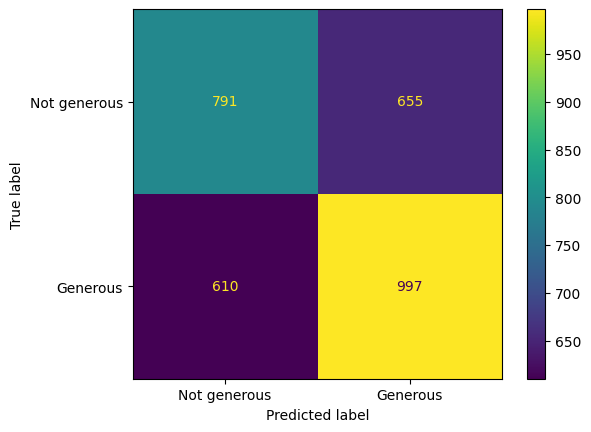

In [86]:
# investigation cell
# Confusion matrix — XGBoost without VendorID
cm_novendor = confusion_matrix(y_test, novendor_preds)
disp_novendor = ConfusionMatrixDisplay(confusion_matrix=cm_novendor, display_labels=['Not generous', 'Generous'])
disp_novendor.plot()
plt.show()

Get the best score from this model.

In [57]:
# Examine best score
xgb_cv.best_score_

0.7347889008091044

And the best parameters.

In [58]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 3,
 'n_estimators': 300}

##### XGB CV Results

Use the `make_results()` function to output all of the scores of your model. Note that it accepts three arguments. 

In [59]:
# Call 'make_results()' on the GridSearch object
xgb_results = make_results('XGB CV', xgb_cv, 'f1')
xgb_results

,model,precision,recall,F1,accuracy
0,XGB CV,0.691747,0.783603,0.734789,0.70226


XGBoost edges out random forest across all four validation metrics — precision (0.692 vs 0.680), recall (0.784 vs 0.775), F1 (0.735 vs 0.724), and accuracy (0.702 vs 0.689). The margins are modest, not dramatic, but consistent in the same direction across every metric — a reasonable early signal that XGBoost may be the stronger model here, though the real test is how it holds up on the held-out test set, same as RF.

Use your model to predict on the test data. Assign the results to a variable called `xgb_preds`.

<details>
  <summary><h5>HINT</h5></summary>
    
You cannot call `predict()` on the GridSearchCV object directly. You must call it on the `best_estimator_`.
</details>

In [60]:
# Get scores on test data
xgb_preds = xgb_cv.best_estimator_.predict(X_test)

###### XGB test results

1. Use the `get_test_scores()` function to generate the scores on the test data. Assign the results to `xgb_test_scores`.
2. Call `xgb_test_scores` to output the results.

In [61]:
# Get scores on test data
xgb_test_scores = get_test_scores('XGB test', xgb_preds, y_test)
xgb_test_scores

,model,precision,recall,F1,accuracy
0,XGB test,0.693834,0.805227,0.745392,0.710449


XGBoost wins again, and by a slightly wider margin than at validation — precision 0.694 vs 0.690, recall 0.805 vs 0.790, F1 0.745 vs 0.737, accuracy 0.710 vs 0.703. Same pattern as RF: test scores landed close to (and even slightly above) validation scores, which is a second confirmation that XGBoost is generalizing well, not overfitting.

**Question:** Compare these scores to the random forest test scores. What do you notice? Which model would you choose?

XGBoost outperformed random forest on every test metric: precision (0.694 vs 0.690), recall (0.805 vs 0.790), F1 (0.745 vs 0.737), and accuracy (0.710 vs 0.703). The margins are modest but consistent across all four metrics and hold at both the validation and test stage, suggesting XGBoost is a genuinely — if modestly — stronger model rather than a result of chance variation between the two.

Given the F1 priority established in the Plan stage, XGBoost is the recommended model. Its recall advantage (0.805 vs 0.790) is also worth noting specifically: recall governs how many actually-generous tippers get correctly identified, and since the false-negative case (a genuinely generous rider being skipped over) was identified as carrying real customer-facing harm, XGBoost's edge here is a meaningful practical advantage, not just a marginally better number.


Plot a confusion matrix of the model's predictions on the test data.

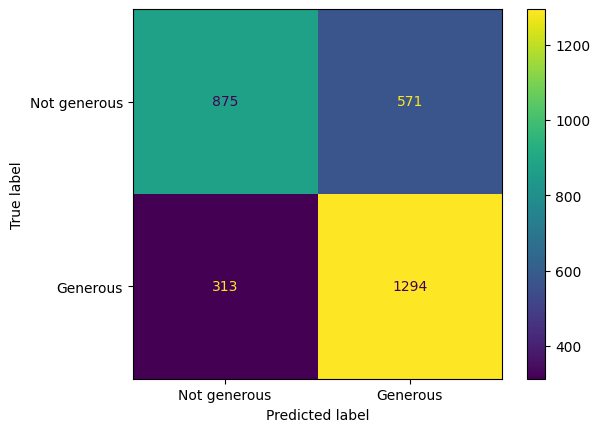

In [62]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, xgb_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not generous', 'Generous'])
disp.plot()
plt.show()

True negatives (correctly predicted not generous): 875
False positives (predicted generous, actually not): 571
False negatives (predicted not generous, actually generous): 313
True positives (correctly predicted generous): 1294

False positives (571) are nearly double the false negatives (313). This is worth pausing on, because it's not just a technical detail — it directly ties back to the cost asymmetry established in the Plan stage. False positives are the error where a driver expects a good tip and doesn't get one, which was identified as the costlier outcome for driver trust in the tool. The model currently produces more of that costlier error than the other kind, not fewer.

**Question:** What type of errors are more common for your model?

False positives are more common than false negatives (571 vs. 313). The model is more likely to predict a rider will be generous when they actually aren't, than to miss an actually-generous rider. This is a meaningful limitation given the Plan-stage finding that false positives carry the higher real-world cost — a driver expecting a good tip and not receiving one. While F1 was chosen specifically because both error types were judged comparably costly, the model's actual error distribution skews toward the costlier error type in practice, which is worth flagging as a real limitation rather than a purely technical footnote — this belongs in the executive summary, not just this cell.

##### Feature importance

Use the `feature_importances_` attribute of the best estimator object to inspect the features of your final model. You can then sort them and plot the most important ones.

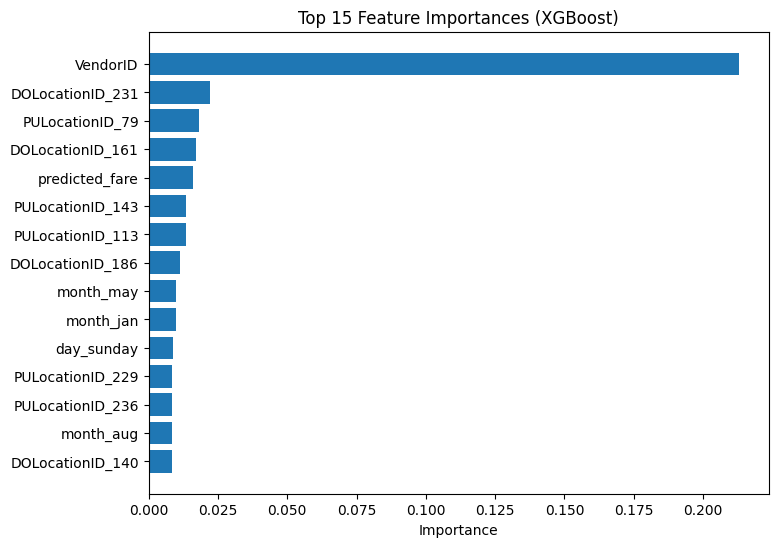

In [63]:
# Plot feature importance
importances = xgb_cv.best_estimator_.feature_importances_
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

VendorID dominates by a wide margin — roughly 0.20+ importance, several times higher than every other feature, most of which cluster around 0.02–0.03. Per the data dictionary, VendorID just identifies which of two TPEP technology providers (Creative Mobile Technologies vs. VeriFone) supplied the trip record. There's no obvious reason a payment vendor's identity should be the single strongest predictor of whether someone tips generously — riders don't choose their vendor, and it's not a proxy for anything about the rider or trip itself.

A plausible explanation worth naming rather than ignoring: NYC taxi payment terminals from different vendors are known to present different default/suggested tip percentages on the in-cab screen (e.g., preset buttons like 20%/25%/30%). If one vendor's terminal defaults nudge riders toward hitting the ≥20% threshold more often than the other's, the model would be picking up a UI/technology artifact, not genuine rider generosity. That's a hypothesis, not a confirmed fact — but it's exactly the kind of finding that belongs in the executive summary as a caveat: the model's top feature may reflect how the payment happened more than who the rider is.

Two other things worth noting for the conclusion:

predicted_fare shows up as a real contributor — confirms the Course 4 pre-ride estimate is pulling weight, not just sitting there unused.
Location features are present but individually modest — no single PULocationID/DOLocationID dummy comes close to VendorID's importance. The equity/proxy risk from your ethics answer is real, but it's diffuse across many small-weight zone variables rather than concentrated in one dominant feature — worth stating precisely rather than overstating.

<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 4. Conclusion**

In this step, use the results of the models above to formulate a conclusion. Consider the following questions:

1. Would you recommend using this model? Why or why not?

Conditionally, yes — with specific caveats that should accompany any deployment. XGBoost achieved solid, consistent performance (F1 0.745 on test data, all four metrics above the 0.65 acceptability bar, and test scores closely matching validation scores, indicating the model generalizes well rather than overfitting). That said, three limitations should shape how it's used:

Scope is limited to credit-card payers. Cash tips aren't recorded in this dataset, so the model has no ground truth — and therefore no validated accuracy — for roughly a third of riders.
False positives (571) outnumber false negatives (313) — meaning the model produces more of the costlier error type (a driver expecting a good tip and not receiving one) than the less costly one, even after optimizing for F1.
The top predictive feature, VendorID, has no obvious causal link to rider generosity and may reflect differences in each payment vendor's in-cab tip-suggestion interface rather than genuine rider behavior. This warrants investigation before the model is trusted at face value.

Recommendation: deploy as an informational tool only — surfacing a likelihood estimate to drivers — not as a mechanism that determines who gets picked up or how a rider is treated. That guards against the discrimination-proxy risk raised in the ethics discussion, regardless of how the model's internals get resolved.

2. What was your model doing? Can you explain how it was making predictions?

The model is an XGBoost classifier, a form of gradient boosting: rather than building one decision tree, it builds many small trees in sequence, where each new tree focuses specifically on correcting the mistakes the previous trees made. The final prediction combines all trees' outputs into a single probability, which gets thresholded into "generous" or "not generous."

In practice, the model splits riders into groups based on combinations of feature values — most heavily VendorID, followed by specific pickup/dropoff zones, the Course 4 predicted fare, and time-based features like month and day. Each split asks something like "does this trip have VendorID = 2, and did it drop off in zone 231?" — and riders who share enough of these characteristics end up grouped together with a similar predicted likelihood of tipping generously.

3. Are there new features you can engineer that might improve performance?

A few directions worth trying:

Interaction features, such as combining specific pickup–dropoff zone pairs (route) rather than treating each location independently — a route might matter more than either endpoint alone.
Weekday vs. weekend as a single binary flag, in addition to the individual day-of-week dummies, in case weekend/weekday is a stronger signal than the specific day.
Binned versions of predicted_fare and mean_distance, to test whether tipping generosity has threshold effects (e.g., short trips vs. long trips) rather than a purely linear relationship.
A holiday flag, since tipping behavior around holidays may differ from an ordinary day in the same month.

4. What features would you want to have that would likely improve performance?

Rider-level tipping history, if available — whether this rider (or similar riders) has a track record of generous tipping is likely a stronger signal than any trip-level feature currently in the dataset.
Weather and real-time demand conditions at time of pickup, which could plausibly influence tipping behavior but aren't captured here.
The full 408,294-row dataset, rather than this ~22,700-row sample — more data, particularly across a fuller range of PULocationID/DOLocationID combinations, would likely sharpen the location-based features specifically.
Documentation of each vendor's payment-terminal tip-suggestion interface, to directly test the hypothesis that VendorID's outsized importance reflects UI design rather than genuine rider behavior — this would either validate or rule out the biggest open question this model raised.  

Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion. Even if you cannot use the model to make strong predictions, was the work done in vain? Consider any insights that you could report back to stakeholders.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.